# Chapter 12: Stocks, Flows, Sources, and Sinks

*Systems Thinking with AI* by Jason Karpeles

Every flow names two endpoints and a unit with a time base, and the accounting can then check itself.

**Goal.** Four small systems run through the chapter's own structural checks. A tub with no drain only grows, a drain into an undeclared name leaves a conservation residual, a clamped stock creates goods that a limited flow does not, and a rate only becomes an amount when it is multiplied by a time.

**Demonstrations**

1. A tub with no drain can only grow
2. Conservation as an executable claim
3. A clamp hides a mechanism; a limited flow names it
4. Units as a type system: a rate times a time

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/12-stocks-flows/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/12-stocks-flows/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_12_stocks_flows/code/system.py`

In [2]:
%%module chapters.chapter_12_stocks_flows.code.system
"""A stock-and-flow system that knows where every flow starts and ends.

Every flow connects two endpoints. An endpoint is either a stock in the model or a
named boundary: a source outside the model that supplies, or a sink outside that
absorbs. A flow with an unnamed endpoint is the defect this module exists to find.
"""

from dataclasses import dataclass, field

SOURCE = "__source__"
SINK = "__sink__"


@dataclass(frozen=True)
class Flow:
    """A rate moving a quantity from one endpoint to another."""

    name: str
    origin: str
    destination: str
    unit: str

    def __post_init__(self) -> None:
        if not self.name.strip() or not self.unit.strip():
            raise ValueError("a flow needs a name and a unit per time")
        if self.origin == self.destination:
            raise ValueError("a flow must move a quantity between two endpoints")
        if "/" not in self.unit or not all(part.strip() for part in self.unit.rsplit("/", 1)):
            raise ValueError(f"'{self.unit}' is not a rate: a flow's unit needs a time base")


@dataclass
class System:
    """A set of named stocks and the flows that move quantities between them."""

    stocks: dict[str, float] = field(default_factory=dict)
    flows: list[Flow] = field(default_factory=list)
    unit: str = "units"
    time_unit: str | None = None

    def endpoints(self) -> set[str]:
        return set(self.stocks) | {SOURCE, SINK}

    def dangling(self) -> list[str]:
        """Flows naming an endpoint that is neither a stock nor a declared boundary."""
        known = self.endpoints()
        return [f.name for f in self.flows if f.origin not in known or f.destination not in known]

    def unsunk_stocks(self) -> list[str]:
        """Stocks that can be filled and never emptied. The missing-sink defect."""
        has_out = {f.origin for f in self.flows}
        has_in = {f.destination for f in self.flows}
        return sorted(name for name in self.stocks if name in has_in and name not in has_out)

    def unsourced_stocks(self) -> list[str]:
        """Stocks that can be emptied and never filled."""
        has_out = {f.origin for f in self.flows}
        has_in = {f.destination for f in self.flows}
        return sorted(name for name in self.stocks if name in has_out and name not in has_in)

    def check(self) -> list[str]:
        """Endpoint, one-way-stock, and exact unit-label checks before simulation."""
        problems = [f"flow '{n}' names an endpoint that does not exist" for n in self.dangling()]
        problems += [f"stock '{n}' has no outflow: it can only grow" for n in self.unsunk_stocks()]
        problems += [
            f"stock '{n}' has no inflow: it can only shrink" for n in self.unsourced_stocks()
        ]
        problems += self.unit_problems()
        return problems

    def unit_problems(self) -> list[str]:
        """Check exact quantity and time labels; no unit conversion is performed."""
        problems = []
        time_bases = set()
        for flow in self.flows:
            quantity, time_base = (part.strip() for part in flow.unit.rsplit("/", 1))
            if quantity != self.unit:
                problems.append(f"flow unit '{flow.unit}' does not match system unit '{self.unit}'")
            time_bases.add(time_base)
            if self.time_unit is not None and time_base != self.time_unit:
                problems.append(
                    f"flow '{flow.name}' uses '{time_base}', expected '{self.time_unit}'"
                )
        if len(time_bases) > 1:
            problems.append(
                f"mixed flow time bases require explicit conversion: {sorted(time_bases)}"
            )
        return problems

    def step(self, rates: dict[str, float], dt: float = 1.0) -> "System":
        """Advance every stock using flows read from the current state."""
        unit_errors = self.unit_problems()
        if unit_errors:
            raise ValueError("; ".join(unit_errors))
        missing = {f.name for f in self.flows} - set(rates)
        if missing:
            raise ValueError(f"no rate supplied for: {sorted(missing)}")
        if dt <= 0:
            raise ValueError("dt must be positive")
        updated = dict(self.stocks)
        for flow in self.flows:
            moved = dt * rates[flow.name]
            if flow.origin in updated:
                updated[flow.origin] -= moved
            if flow.destination in updated:
                updated[flow.destination] += moved
        return System(stocks=updated, flows=self.flows, unit=self.unit, time_unit=self.time_unit)


def total_in_system(system: System) -> float:
    """Everything currently held inside the boundary."""
    return sum(system.stocks.values())


def conservation_residual(
    before: System, after: System, rates: dict[str, float], dt: float = 1.0
) -> float:
    """What entered from sources minus what left to sinks, against the change in total.

    Returns 0.0 when the accounting closes. Anything else means a quantity appeared
    or vanished without crossing a declared boundary.
    """
    crossed_in = sum(dt * rates[f.name] for f in before.flows if f.origin == SOURCE)
    crossed_out = sum(dt * rates[f.name] for f in before.flows if f.destination == SINK)
    expected = crossed_in - crossed_out
    return (total_in_system(after) - total_in_system(before)) - expected


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [3]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [4]:
"""Chapter 12 reader: stocks, flows, sources and sinks, checked structurally.

Every number comes from the Chapter 12 pack (System, Flow, check, step,
conservation_residual) so the reader, the pack and the book agree.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed

from chapters.chapter_12_stocks_flows.code.system import (
    SINK,
    SOURCE,
    Flow,
    System,
    conservation_residual,
    total_in_system,
)

EQ_CHECK = "bathtub.check()"
EQ_STEP = "bathtub.step(rates)"
EQ_RESIDUAL = "conservation_residual(bathtub, after, rates)"
EQ_TOTAL = "total_in_system(after)"


# Demonstration 1: a tub with no drain only grows.

def missing_drain(tap=10.0, drain="present"):
    flows = [Flow("tap", SOURCE, "tub", "litres/minute")]
    rates = {"tap": float(tap)}
    if drain == "present":
        flows.append(Flow("drain", "tub", SINK, "litres/minute"))
        rates["drain"] = 4.0
    system = System(stocks={"tub": 50.0}, flows=flows, unit="litres")
    problems = system.check()
    levels = [system.stocks["tub"]]
    for _ in range(8):
        system = system.step(rates)
        levels.append(system.stocks["tub"])
    minutes = np.arange(0, 9)

    fig, ax = new_figure()
    ax.plot(minutes, levels, marker="o", color=PALETTE["navy"] if drain == "present" else PALETTE["terracotta"])
    label_point(ax, 8, levels[-1], f"{fmt(levels[-1], 0)} l", color=PALETTE["ink"], dx=-6, dy=-14,
                ha="right", va="top")
    label_point(ax, 0, levels[0], "start 50 l", color=PALETTE["ink"], dx=6, dy=8)
    ax.set_xlim(-0.3, 8.3)
    ax.set_ylim(0, 175)
    ax.set_xlabel("Minute")
    ax.set_ylabel("Water in the tub (litres)")

    net = rates["tap"] - rates.get("drain", 0.0)
    if drain == "present":
        direction = ("The level does not move, because the tap and the drain tie." if net == 0
                     else ("The level rises." if net > 0 else "The level falls."))
        calc = (f"Net flow = {fmt(tap, 0)} - 4 = {signed(net, 0)} litres per minute, so after 8 minutes the level "
                f"is 50 + 8 x {signed(net, 0)} = {fmt(levels[-1], 0)} litres. {direction}")
    else:
        calc = (f"With no drain the net flow is the tap alone: after 8 minutes the level is 50 + 8 x "
                f"{fmt(tap, 0)} = {fmt(levels[-1], 0)} litres, and it would keep rising. check() reports: "
                f"{problems[0]}.")
    metrics = {
        "Structural check": "; ".join(problems) if problems else "no problems",
        "Net flow (l/min)": signed(net, 0),
        "Level after 8 minutes (l)": fmt(levels[-1], 0),
    }
    return fig, metrics, calc


# Demonstration 2: conservation needs both endpoints declared.

def endpoint_accounting(drain=4.0, drain_goes_to="sink"):
    destination = SINK if drain_goes_to == "sink" else "sewer"
    before = System(
        stocks={"tub": 50.0},
        flows=[Flow("tap", SOURCE, "tub", "litres/minute"), Flow("drain", "tub", destination, "litres/minute")],
        unit="litres",
    )
    rates = {"tap": 10.0, "drain": float(drain)}
    after = before.step(rates)
    residual = conservation_residual(before, after, rates)
    problems = before.check()
    inside = total_in_system(after) - total_in_system(before)
    crossing = inside - residual

    fig, ax = new_figure()
    xs = [0, 1]
    heights = [inside, crossing]
    ax.axhline(0, color=PALETTE["grey"], linewidth=1.2)
    ax.bar(xs, heights, width=0.5, color=[PALETTE["navy"], PALETTE["teal"]])
    for x, v in zip(xs, heights):
        ax.annotate(fmt(v, 0), (x, v), xytext=(0, 5 if v >= 0 else -16), textcoords="offset points",
                    ha="center", fontsize=10.5)
    ax.set_xticks(xs, ["Change inside\nthe boundary", "Net crossing at declared\nsource and sink"])
    ax.set_ylim(-3, 14)
    ax.set_xlabel(f"Residual = {signed(residual, 0)} litres")
    ax.set_ylabel("Litres in one minute")

    if residual == 0:
        tail = "The accounting closes: the residual is zero."
    else:
        tail = (f"The residual is {signed(residual, 0)}: {fmt(abs(residual), 0)} litres left the tub and crossed "
                f"no declared boundary, so they vanished.")
    metrics = {
        "Drain empties into": "declared sink" if drain_goes_to == "sink" else "a name that is not declared",
        "Change in the total (l)": signed(inside, 0),
        "Net crossing at declared boundary (l)": signed(crossing, 0),
        "Conservation residual (l)": signed(residual, 0),
        "Structural check": "; ".join(problems) if problems else "no problems",
    }
    interpretation = (
        f"The total inside changes by (50 + 10 - {fmt(drain, 0)}) - 50 = {signed(inside, 0)}. The tap crosses "
        f"in 10 and the declared sink takes out {fmt(drain if drain_goes_to == 'sink' else 0, 0)}, so the "
        f"expected change is 10 - {fmt(drain if drain_goes_to == 'sink' else 0, 0)} = {signed(crossing, 0)}. "
        f"Residual = {signed(inside, 0)} - {signed(crossing, 0)} = {signed(residual, 0)}. {tail}"
    )
    return fig, metrics, interpretation


# Demonstration 3: a clamped stock breaks conservation; a limited flow keeps it.

def clamp_or_limit(requested=70.0, method="clamp"):
    flows = [Flow("production", SOURCE, "inventory", "units/week"),
             Flow("shipments", "inventory", SINK, "units/week")]
    before = System(stocks={"inventory": 40.0}, flows=flows, unit="units")
    production = 10.0
    if method == "clamp":
        rates = {"production": production, "shipments": float(requested)}
        raw = before.step(rates)
        inv = max(0.0, raw.stocks["inventory"])
        after = System(stocks={"inventory": inv}, flows=flows, unit="units")
        unmet = 0.0
        shipped = float(requested)
    else:
        shipped = min(float(requested), before.stocks["inventory"])
        rates = {"production": production, "shipments": shipped}
        after = before.step(rates)
        unmet = float(requested) - shipped
    residual = conservation_residual(before, after, rates)
    inv = after.stocks["inventory"]

    fig, ax = new_figure()
    labels = ["Inventory\nafter the week", "Unmet orders\nheld as backlog", "Goods created\nfrom nothing"]
    vals = [inv, unmet, residual]
    ax.bar([0, 1, 2], vals, width=0.5, color=[PALETTE["navy"], PALETTE["teal"], PALETTE["terracotta"]])
    for x, v in enumerate(vals):
        ax.annotate(fmt(v, 0), (x, v), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=10.5)
    ax.set_xticks([0, 1, 2], labels)
    ax.set_ylim(0, 48)
    ax.set_xlabel("Inventory 40, production 10 per week")
    ax.set_ylabel("Units")

    if method == "clamp":
        raw_level = 40.0 + production - requested
        if raw_level >= 0:
            tail = ("The inventory stayed at or above zero, so the clamp did nothing"
                    + (" (it landed exactly on zero, a tie)." if raw_level == 0 else "."))
        else:
            tail = f"The clamp raised the stock from {signed(raw_level, 0)} to 0, which created {fmt(residual, 0)} units."
        interpretation = (
            f"Stock before clamping = 40 + 10 - {fmt(requested, 0)} = {signed(raw_level, 0)}; the clamp holds it at "
            f"{fmt(inv, 0)}. Change in the total = {fmt(inv, 0)} - 40 = {signed(inv - 40, 0)}; expected from the "
            f"boundary = 10 - {fmt(requested, 0)} = {signed(production - requested, 0)}. Residual = "
            f"{signed(inv - 40, 0)} - {signed(production - requested, 0)} = {signed(residual, 0)}. {tail}"
        )
    else:
        tail = ("Every order could be filled." if unmet == 0 else
                f"{fmt(unmet, 0)} units of demand could not be filled and wait as backlog.")
        interpretation = (
            f"Shipments are limited to what is on hand: min({fmt(requested, 0)}, 40) = {fmt(shipped, 0)}. "
            f"Inventory = 40 + 10 - {fmt(shipped, 0)} = {fmt(inv, 0)}. Residual = ({fmt(inv, 0)} - 40) - "
            f"(10 - {fmt(shipped, 0)}) = {signed(residual, 0)}. {tail}"
        )
    metrics = {
        "Requested shipments (units)": fmt(requested, 0),
        "Shipped (units)": fmt(shipped, 0),
        "Inventory after the week": fmt(inv, 0),
        "Unmet orders (units)": fmt(unmet, 0),
        "Conservation residual (units)": signed(residual, 0),
    }
    return fig, metrics, interpretation


# Demonstration 4: a rate times a time gives an amount.

def rate_times_time(dt=1.0, keep_dt="kept"):
    flows = [Flow("production", SOURCE, "inventory", "units/week")]
    start = System(stocks={"inventory": 200.0}, flows=flows, unit="units")
    kept = start.step({"production": 40.0}, dt=dt).stocks["inventory"]
    dropped = 200.0 + 40.0
    shown = kept if keep_dt == "kept" else dropped
    try:
        Flow("production", SOURCE, "inventory", "units")
        refusal = "accepted"
    except ValueError:
        refusal = "refused (no time base)"

    fig, ax = new_figure()
    grid = np.linspace(0.25, 4.25, 41)
    ax.plot(grid, 200 + 40 * grid, color=PALETTE["navy"])
    ax.plot(grid, np.full_like(grid, dropped), color=PALETTE["terracotta"], linestyle="dashed")
    ax.plot([dt], [shown], marker="o", markersize=10, color=PALETTE["ink"])
    label_point(ax, 3.2, 200 + 40 * 3.2, "dt kept", color=PALETTE["navy"], dx=4, dy=-8, ha="left", va="top")
    label_point(ax, 3.2, dropped, "dt dropped", color=PALETTE["terracotta"], dx=4, dy=-8, ha="left", va="top")
    label_point(ax, dt, shown, f"{fmt(shown, 0)} units", color=PALETTE["ink"],
                dx=(10 if dt < 2 else -10), dy=10, ha=("left" if dt < 2 else "right"))
    ax.set_xlim(0, 4.5)
    ax.set_ylim(180, 400)
    ax.set_xlabel("Length of the step (weeks)")
    ax.set_ylabel("Inventory after one step (units)")

    if keep_dt == "kept":
        interpretation = (
            f"Inventory = 200 + {fmt(dt, 2)} x 40 = 200 + {fmt(dt * 40, 0)} = {fmt(kept, 0)} units. "
            f"The weeks cancel, so the sum is in units."
        )
    else:
        tail = ("At a one week step the dropped version happens to agree, a tie that hides the defect."
                if dt == 1.0 else
                f"The correct answer for a {fmt(dt, 2)} week step is {fmt(kept, 0)}, so it is off by "
                f"{signed(dropped - kept, 0)}.")
        interpretation = (
            f"Dropping dt adds the rate itself: 200 + 40 = {fmt(dropped, 0)} units, whatever the step. {tail}"
        )
    metrics = {
        "Step length (weeks)": fmt(dt, 2),
        "Correct inventory (units)": fmt(kept, 0),
        "Inventory with dt dropped (units)": fmt(dropped, 0),
        "Shown": fmt(shown, 0),
        "A flow unit of just 'units'": refusal,
    }
    return fig, metrics, interpretation


## 1. A tub with no drain can only grow

*What does the structural check say about a stock that has an inflow and no outflow?*

A stock that appears as a flow destination and never as an origin can only grow. The check finds it before any step runs, and the stepped levels show the growth it would hide.

    bathtub.check()

**Symbols and inputs.** The tub holds 50 litres. The tap supplies litres per minute from a source outside the boundary; the drain, when present, removes 4 litres per minute to a sink.

**Predict first.** With the tap at 10 and no drain, does check() return an empty list?

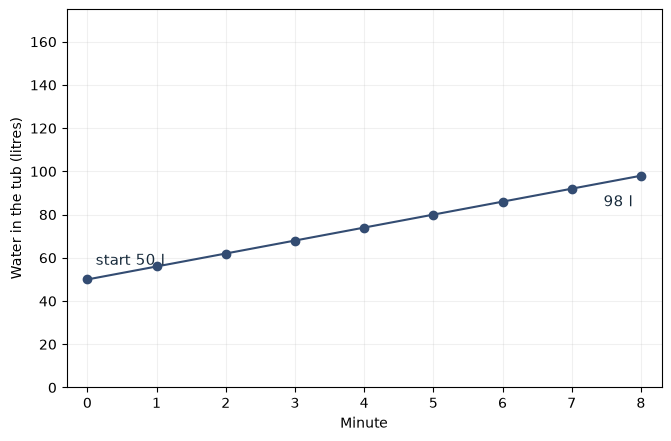

- **Structural check:** no problems
- **Net flow (l/min):** 6
- **Level after 8 minutes (l):** 98

Net flow = 10 - 4 = 6 litres per minute, so after 8 minutes the level is 50 + 8 x 6 = 98 litres. The level rises.

In [5]:
show(missing_drain(tap=10.0, drain='present'))

**Use the idea.** Run the structural check each time a stock or flow is added, and confirm any stock that can only grow or only shrink is meant to.

**Where the conclusion applies.** Eight one-minute steps with constant rates. A cumulative counter legitimately only grows, so the message is a prompt to confirm intent, not a verdict.

*Constructed example: the chapter's bathtub, with tap rates and a drain rate of 4 chosen for this reader.*

Every setting the interactive reader offers for this demonstration:

In [6]:
sweep(missing_drain, [('tap', [4.0, 10.0, 14.0]), ('drain', ['present', 'missing'])])

- **tap = 4.0, drain = present**: Structural check no problems; Net flow (l/min) 0; Level after 8 minutes (l) 50
- **tap = 4.0, drain = missing**: Structural check stock 'tub' has no outflow: it can only grow; Net flow (l/min) 4; Level after 8 minutes (l) 82
- **tap = 10.0, drain = present**: Structural check no problems; Net flow (l/min) 6; Level after 8 minutes (l) 98
- **tap = 10.0, drain = missing**: Structural check stock 'tub' has no outflow: it can only grow; Net flow (l/min) 10; Level after 8 minutes (l) 130
- **tap = 14.0, drain = present**: Structural check no problems; Net flow (l/min) 10; Level after 8 minutes (l) 130
- **tap = 14.0, drain = missing**: Structural check stock 'tub' has no outflow: it can only grow; Net flow (l/min) 14; Level after 8 minutes (l) 162

## 2. Conservation as an executable claim

*What does the residual say when a flow ends at a name that was never declared?*

The step moves litres out of the tub either way. Only a declared sink is counted as a crossing, so an undeclared destination leaves the outflow unexplained and the residual equals minus the drain.

    conservation_residual(bathtub, after, rates)

**Symbols and inputs.** The residual is the change in the total inside the boundary minus what crossed the boundary at declared sources and sinks. The tap supplies 10 litres in the minute; the drain removes the chosen amount.

**Predict first.** If the drain empties into an undeclared name at 7 litres per minute, what is the residual?

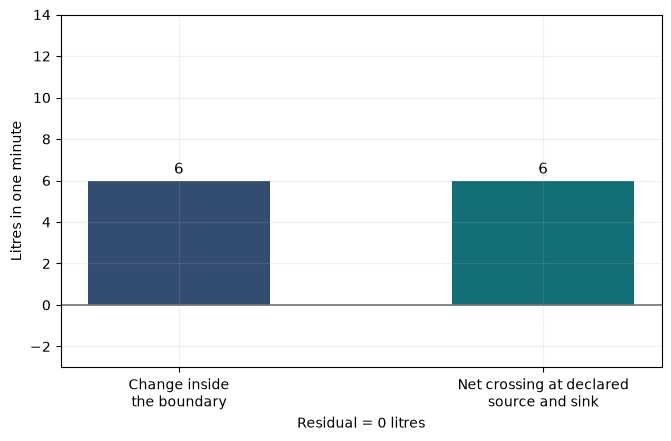

- **Drain empties into:** declared sink
- **Change in the total (l):** 6
- **Net crossing at declared boundary (l):** 6
- **Conservation residual (l):** 0
- **Structural check:** no problems

The total inside changes by (50 + 10 - 4) - 50 = 6. The tap crosses in 10 and the declared sink takes out 4, so the expected change is 10 - 4 = 6. Residual = 6 - 6 = 0. The accounting closes: the residual is zero.

In [7]:
show(endpoint_accounting(drain=4.0, drain_goes_to='sink'))

**Use the idea.** Test the residual in every model with a transfer, since a flow forgotten at one end still runs and still looks plausible.

**Where the conclusion applies.** One minute, one tub, constant rates. The residual detects a missing endpoint; it cannot say whether a declared source or sink is a realistic simplification.

*Constructed example: the chapter's bathtub step, with the drain rate and its destination varied for this reader.*

Every setting the interactive reader offers for this demonstration:

In [8]:
sweep(endpoint_accounting, [('drain', [4.0, 7.0, 10.0]), ('drain_goes_to', ['sink', 'undeclared'])])

- **drain = 4.0, drain_goes_to = sink**: Drain empties into declared sink; Change in the total (l) 6; Net crossing at declared boundary (l) 6; Conservation residual (l) 0; Structural check no problems
- **drain = 4.0, drain_goes_to = undeclared**: Drain empties into a name that is not declared; Change in the total (l) 6; Net crossing at declared boundary (l) 10; Conservation residual (l) (-4); Structural check flow 'drain' names an endpoint that does not exist
- **drain = 7.0, drain_goes_to = sink**: Drain empties into declared sink; Change in the total (l) 3; Net crossing at declared boundary (l) 3; Conservation residual (l) 0; Structural check no problems
- **drain = 7.0, drain_goes_to = undeclared**: Drain empties into a name that is not declared; Change in the total (l) 3; Net crossing at declared boundary (l) 10; Conservation residual (l) (-7); Structural check flow 'drain' names an endpoint that does not exist
- **drain = 10.0, drain_goes_to = sink**: Drain empties into declared sink; Change in the total (l) 0; Net crossing at declared boundary (l) 0; Conservation residual (l) 0; Structural check no problems
- **drain = 10.0, drain_goes_to = undeclared**: Drain empties into a name that is not declared; Change in the total (l) 0; Net crossing at declared boundary (l) 10; Conservation residual (l) (-10); Structural check flow 'drain' names an endpoint that does not exist

## 3. A clamp hides a mechanism; a limited flow names it

*When shipments exceed inventory, what is the difference between flooring the stock and limiting the flow?*

A clamped stock discards the deficit, so the total no longer matches what crossed the boundary. A limited flow ships only what exists and the unmet demand is kept as backlog, so the residual stays zero.

    conservation_residual(bathtub, after, rates)

**Symbols and inputs.** Inventory starts at 40 units and production adds 10 per week. Requested shipments are the chosen number. A clamp holds the stock at zero; a limited flow ships no more than is on hand.

**Predict first.** With 70 requested and the stock clamped at zero, how many units does the residual say were created?

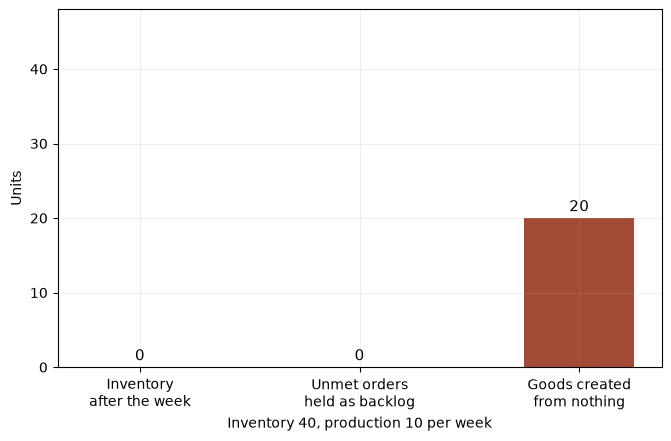

- **Requested shipments (units):** 70
- **Shipped (units):** 70
- **Inventory after the week:** 0
- **Unmet orders (units):** 0
- **Conservation residual (units):** 20

Stock before clamping = 40 + 10 - 70 = (-20); the clamp holds it at 0. Change in the total = 0 - 40 = (-40); expected from the boundary = 10 - 70 = (-60). Residual = (-40) - (-60) = 20. The clamp raised the stock from (-20) to 0, which created 20 units.

In [9]:
show(clamp_or_limit(requested=70.0, method='clamp'))

**Use the idea.** Express a bound on the flow, and decide what happens to the demand that was not met, instead of clamping the stock.

**Where the conclusion applies.** One week, shipments read from the starting inventory, and unmet orders simply waiting. In a real warehouse unmet orders may be cancelled, which is a further flow to declare.

*Constructed example: the chapter's warehouse argument with inventory, production and request sizes defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(clamp_or_limit, [('requested', [30.0, 50.0, 70.0]), ('method', ['clamp', 'limit'])])

- **requested = 30.0, method = clamp**: Requested shipments (units) 30; Shipped (units) 30; Inventory after the week 20; Unmet orders (units) 0; Conservation residual (units) 0
- **requested = 30.0, method = limit**: Requested shipments (units) 30; Shipped (units) 30; Inventory after the week 20; Unmet orders (units) 0; Conservation residual (units) 0
- **requested = 50.0, method = clamp**: Requested shipments (units) 50; Shipped (units) 50; Inventory after the week 0; Unmet orders (units) 0; Conservation residual (units) 0
- **requested = 50.0, method = limit**: Requested shipments (units) 50; Shipped (units) 40; Inventory after the week 10; Unmet orders (units) 10; Conservation residual (units) 0
- **requested = 70.0, method = clamp**: Requested shipments (units) 70; Shipped (units) 70; Inventory after the week 0; Unmet orders (units) 0; Conservation residual (units) 20
- **requested = 70.0, method = limit**: Requested shipments (units) 70; Shipped (units) 40; Inventory after the week 10; Unmet orders (units) 30; Conservation residual (units) 0

## 4. Units as a type system: a rate times a time

*What goes wrong when forty units per week is added straight to an inventory of two hundred?*

Kept, dt turns the rate into an amount and the inventory grows with the step length. Dropped, the update always adds 40, so only a one week step gives the right answer, by coincidence.

    bathtub.step(rates)

**Symbols and inputs.** Inventory is in units. Production is 40 units per week. dt is the length of the step in weeks, so dt x 40 is a number of units.

**Predict first.** At a two week step with dt dropped, how many units does the inventory show?

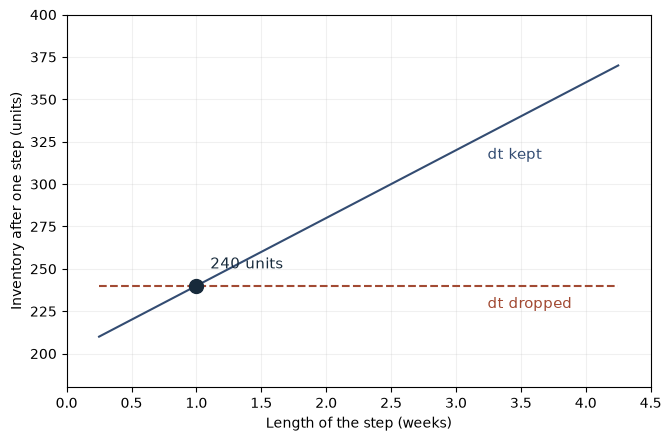

- **Step length (weeks):** 1.00
- **Correct inventory (units):** 240
- **Inventory with dt dropped (units):** 240
- **Shown:** 240
- **A flow unit of just 'units':** refused (no time base)

Inventory = 200 + 1.00 x 40 = 200 + 40 = 240 units. The weeks cancel, so the sum is in units.

In [11]:
show(rate_times_time(dt=1.0, keep_dt='kept'))

**Use the idea.** Make the unit a required field on every flow so that a rate without a time base is refused where it is written.

**Where the conclusion applies.** A constant production rate and a single step from 200 units. The constructor check catches a missing time base, but not a flow whose unit is wrong in some other way.

*Constructed example: the chapter's 40 units per week and 200 units, with the step length varied for this reader.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(rate_times_time, [('dt', [0.5, 1.0, 2.0, 4.0]), ('keep_dt', ['kept', 'dropped'])])

- **dt = 0.5, keep_dt = kept**: Step length (weeks) 0.50; Correct inventory (units) 220; Inventory with dt dropped (units) 240; Shown 220; A flow unit of just 'units' refused (no time base)
- **dt = 0.5, keep_dt = dropped**: Step length (weeks) 0.50; Correct inventory (units) 220; Inventory with dt dropped (units) 240; Shown 240; A flow unit of just 'units' refused (no time base)
- **dt = 1.0, keep_dt = kept**: Step length (weeks) 1.00; Correct inventory (units) 240; Inventory with dt dropped (units) 240; Shown 240; A flow unit of just 'units' refused (no time base)
- **dt = 1.0, keep_dt = dropped**: Step length (weeks) 1.00; Correct inventory (units) 240; Inventory with dt dropped (units) 240; Shown 240; A flow unit of just 'units' refused (no time base)
- **dt = 2.0, keep_dt = kept**: Step length (weeks) 2.00; Correct inventory (units) 280; Inventory with dt dropped (units) 240; Shown 280; A flow unit of just 'units' refused (no time base)
- **dt = 2.0, keep_dt = dropped**: Step length (weeks) 2.00; Correct inventory (units) 280; Inventory with dt dropped (units) 240; Shown 240; A flow unit of just 'units' refused (no time base)
- **dt = 4.0, keep_dt = kept**: Step length (weeks) 4.00; Correct inventory (units) 360; Inventory with dt dropped (units) 240; Shown 360; A flow unit of just 'units' refused (no time base)
- **dt = 4.0, keep_dt = dropped**: Step length (weeks) 4.00; Correct inventory (units) 360; Inventory with dt dropped (units) 240; Shown 240; A flow unit of just 'units' refused (no time base)

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

With the tap at 14 and the drain present, what is the level after 8 minutes?

<details><summary>Answer</summary>

Net flow = 14 - 4 = 10 per minute, so 50 + 8 x 10 = 130 litres.

</details>

### Exercise 2

With the drain at 10 into an undeclared name, what is the change in the total and what is the residual?

<details><summary>Answer</summary>

The total changes by (50 + 10 - 10) - 50 = 0, the declared crossing is 10, so the residual is 0 - 10 = (-10).

</details>

### Exercise 3

With 60 requested and the flow limited, how many units wait as backlog?

<details><summary>Answer</summary>

Shipped = min(60, 40) = 40, so 60 - 40 = 20 units wait as backlog and the inventory is 40 + 10 - 40 = 10.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/